In this new notebook, I want to do a new iteration of the data analysis from chess.com games. I want to acquire the data from chess.com API, clean and wrangle it, and do a series of analyses - leading to a machine learning model to improve my chess playing skills. 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
raw_chess_nov2 = pd.read_csv('chess_games_20251102_130553.csv')
raw_chess_nov2.head()

,url,pgn,time_control,end_time,rated,tcn,uuid,initial_setup,fen,time_class,...,white.@id,white.username,white.uuid,black.rating,black.result,black.@id,black.username,black.uuid,accuracies.white,accuracies.black
0,https://www.chess.com/game/live/4197707660,"[Event ""Live Chess""]\n[Site ""Chess.com""]\n[Dat...",600,1573411920,True,mC0SfA7Tlt9Igx2MhfMExDSKDJTVcV,ef460c78-5a44-11e6-8000-000000010001,rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w ...,rnb1k1nr/pppp1p1p/7B/2bNp3/2B1P1p1/3P4/PPP2PPP...,blitz,...,https://api.chess.com/pub/player/sanjaykshetri123,Sanjaykshetri123,d03e6f16-03ea-11ea-aff8-896c6f3c9f0c,781,resigned,https://api.chess.com/pub/player/qaswed36,qaswed36,3ae5f74c-8cc9-11e9-9fd5-b1837d950126,NaN,NaN
1,https://www.chess.com/game/live/4197715905,"[Event ""Live Chess""]\n[Site ""Chess.com""]\n[Dat...",60,1573412091,True,mCZRlB5OfOXObs6EdE3NEM1TMl,22d5660a-5a46-11e6-8000-000000010001,rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w ...,r2qkbnr/p1p1p1p1/p2p1p2/7p/3PP3/2N5/PPPQ1PPP/R...,bullet,...,https://api.chess.com/pub/player/petem443,petem443,f0f3c34e-e213-11e9-a76c-35f81d6be07a,591,timeout,https://api.chess.com/pub/player/sanjaykshetri123,Sanjaykshetri123,d03e6f16-03ea-11ea-aff8-896c6f3c9f0c,NaN,NaN
2,https://www.chess.com/game/live/4313325908,"[Event ""Live Chess""]\n[Site ""Chess.com""]\n[Dat...",1800,1576711475,True,mC0KdN5QfA!VltZRcV2UVMUNM7Q7pF6EnvEZbs7Qiq86A1...,9af298a8-9bfd-11e6-8000-000000010001,rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w ...,1k1K4/ppnB4/3p1q2/3b4/8/P4P2/8/8 w - -,rapid,...,https://api.chess.com/pub/player/jarlevikingo,jarlevikingo,9dee3c28-eb21-11e7-802c-000000000000,1021,win,https://api.chess.com/pub/player/sanjaykshetri123,Sanjaykshetri123,d03e6f16-03ea-11ea-aff8-896c6f3c9f0c,NaN,NaN
3,https://www.chess.com/game/live/4313409453,"[Event ""Live Chess""]\n[Site ""Chess.com""]\n[Dat...",1800,1576712983,True,lBZJgv0SbsYQcD9RmuRDuD!Tft3VegWOfe8!dmXHiq98sd...,c2e7f982-9c09-11e6-8000-000000010001,rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w ...,8/5ppk/4p2p/8/n4PP1/p6P/5P1K/2q5 w - -,rapid,...,https://api.chess.com/pub/player/sanjaykshetri123,Sanjaykshetri123,d03e6f16-03ea-11ea-aff8-896c6f3c9f0c,1123,win,https://api.chess.com/pub/player/george4735,george4735,5fafa3c2-180a-11e9-8028-000000000000,NaN,NaN
4,https://www.chess.com/game/live/4313461733,"[Event ""Live Chess""]\n[Site ""Chess.com""]\n[Dat...",180+2,1576713254,True,mC0Kgv5QlB!TBJQzvK9RKt8!bsXPpx98cM6Xfm,5ec93332-9c11-11e6-8000-000000010001,rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w ...,r2qr1k1/pbpp1ppp/1p1b1n2/3P2B1/1n2P3/2NN3P/PPP...,blitz,...,https://api.chess.com/pub/player/bumbumhunter,bumbumhunter,ff7bc4ee-a2ac-11e9-962e-5f9bd9c9f89e,825,timeout,https://api.chess.com/pub/player/sanjaykshetri123,Sanjaykshetri123,d03e6f16-03ea-11ea-aff8-896c6f3c9f0c,NaN,NaN


In [3]:
raw_chess_nov2.tail()

,url,pgn,time_control,end_time,rated,tcn,uuid,initial_setup,fen,time_class,...,white.@id,white.username,white.uuid,black.rating,black.result,black.@id,black.username,black.uuid,accuracies.white,accuracies.black
10731,https://www.chess.com/game/live/144841163270,"[Event ""Live Chess""]\n[Site ""Chess.com""]\n[Dat...",600,1761671899,True,lB!TcDZJmu0Sbs9zgm8!iqzRDMYInvIBdB5QBFR0vD3VMV...,7588ad90-b420-11f0-a829-974a0401000f,rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w ...,6r1/pp5k/5R2/1B1bn2P/4p1q1/P1P5/1P6/1K6 w - - ...,rapid,...,https://api.chess.com/pub/player/sanjaykshetri123,Sanjaykshetri123,d03e6f16-03ea-11ea-aff8-896c6f3c9f0c,1356,win,https://api.chess.com/pub/player/werepanther,Werepanther,17150762-d58a-11e0-8011-000000000000,NaN,NaN
10732,https://www.chess.com/game/live/144848734392,"[Event ""Live Chess""]\n[Site ""Chess.com""]\n[Dat...",600,1761685363,True,mC0Kdv5Qks3Vlt!TfmZRvw6SwF90Fw2Mpx7Zjz86iySrbl...,55374482-b43f-11f0-9d16-2ccca301000f,rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w ...,4n3/2pk1p2/3p4/7p/2PbP3/5P2/1K2B3/R3r2b w - - ...,rapid,...,https://api.chess.com/pub/player/copain2,copain2,88e8f176-a444-11e6-801a-000000000000,1340,win,https://api.chess.com/pub/player/sanjaykshetri123,Sanjaykshetri123,d03e6f16-03ea-11ea-aff8-896c6f3c9f0c,NaN,NaN
10733,https://www.chess.com/game/live/144895305408,"[Event ""Live Chess""]\n[Site ""Chess.com""]\n[Dat...",600,1761788095,True,lBZJcD5QmuWOiq6Lbs!Tpx0Sfm9RDMR0oELUMD0RDMR0nD...,fcf9e02f-b52f-11f0-9a9e-172e6f01000f,rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w ...,2kr3r/1pp3pp/p1n1p3/3p1b2/3P1P2/P3PNqP/1PPKB2R...,rapid,...,https://api.chess.com/pub/player/sanjaykshetri123,Sanjaykshetri123,d03e6f16-03ea-11ea-aff8-896c6f3c9f0c,1310,resigned,https://api.chess.com/pub/player/thalhah123,Thalhah123,34e8ec60-aacd-11ee-8162-83d6894def0a,NaN,NaN
10734,https://www.chess.com/game/live/144895399824,"[Event ""Live Chess""]\n[Site ""Chess.com""]\n[Dat...",600,1761789256,True,mC0Kbs5QfA3Vgv!Tlt9IegZRcuQBuBKBsm6EpxEvov7Zgp...,ad521266-b530-11f0-b3a3-abca2901000f,rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w ...,8/8/Bp6/2k5/2P2p2/4bK2/8/8 b - - 9 73,rapid,...,https://api.chess.com/pub/player/wennnyyyy_the...,Wennnyyyy_the_great102938,9dc4e0c2-e8de-11ef-bde7-2b6cebd71c33,1339,timeout,https://api.chess.com/pub/player/sanjaykshetri123,Sanjaykshetri123,d03e6f16-03ea-11ea-aff8-896c6f3c9f0c,NaN,NaN
10735,https://www.chess.com/game/live/145036221214,"[Event ""Live Chess""]\n[Site ""Chess.com""]\n[Dat...",180,1762102871,True,lB0SgvZJiqYIBI9IjzIRcj!Tks8!px5ZvBWGzH7PqyRImu...,a8335580-b80c-11f0-8516-710fb501000f,rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w ...,8/6R1/1k4p1/pP4Pp/P1PN4/2K5/1B6/8 w - - 0 51,blitz,...,https://api.chess.com/pub/player/sanjaykshetri123,Sanjaykshetri123,d03e6f16-03ea-11ea-aff8-896c6f3c9f0c,1030,win,https://api.chess.com/pub/player/pedronette,pedronette,d94162be-48d1-11e9-a091-cb1ebcd581a1,NaN,NaN


In [4]:
# Examine the dataframe structure to understand time control format
print("📊 Raw Chess Data Overview:")
print(f"Shape: {raw_chess_nov2.shape}")
print(f"Columns: {list(raw_chess_nov2.columns)}")
print("\n⏱️ Time Control Analysis:")
print("Unique time controls:")
if 'time_control' in raw_chess_nov2.columns:
    print(raw_chess_nov2['time_control'].value_counts().head(10))
else:
    # Check for other possible time control column names
    time_cols = [col for col in raw_chess_nov2.columns if 'time' in col.lower()]
    print(f"Time-related columns found: {time_cols}")
    if time_cols:
        print(f"\nSample values from {time_cols[0]}:")
        print(raw_chess_nov2[time_cols[0]].value_counts().head(10))

📊 Raw Chess Data Overview:
Shape: (10736, 24)
Columns: ['url', 'pgn', 'time_control', 'end_time', 'rated', 'tcn', 'uuid', 'initial_setup', 'fen', 'time_class', 'rules', 'eco', 'white.rating', 'white.result', 'white.@id', 'white.username', 'white.uuid', 'black.rating', 'black.result', 'black.@id', 'black.username', 'black.uuid', 'accuracies.white', 'accuracies.black']

⏱️ Time Control Analysis:
Unique time controls:
time_control
600      9993
180       491
1800      158
60         71
300        22
180+2       1
Name: count, dtype: int64


In [8]:
# Calculate total time spent playing chess by converting game durations and summing up
print("⏰ TOTAL TIME SPENT PLAYING CHESS ON CHESS.COM")
print("=" * 60)

# Convert time_control to numeric minutes for calculation
def extract_time_minutes(time_control):
    """Extract base time in minutes from time_control string"""
    if '+' in str(time_control):
        # Handle increment format like "180+2"
        base_time = int(str(time_control).split('+')[0])
    else:
        # Handle simple format like "600"
        base_time = int(time_control)
    return base_time / 60  # Convert seconds to minutes

# Calculate time spent for each dataset
raw_chess_nov2['game_duration_minutes'] = raw_chess_nov2['time_control'].apply(extract_time_minutes)

# Calculate total time metrics
total_games = len(raw_chess_nov2)
total_minutes = raw_chess_nov2['game_duration_minutes'].sum()
total_hours = total_minutes / 60
total_days = total_hours / 24

print(f"📊 OVERALL STATISTICS:")
print(f"  • Total games played: {total_games:,}")
print(f"  • Total time spent: {total_minutes:,.0f} minutes")
print(f"  • Total time spent: {total_hours:,.1f} hours")
print(f"  • Total time spent: {total_days:.1f} days")

print(f"\n🎯 TIME BREAKDOWN BY FORMAT:")
time_breakdown = raw_chess_nov2.groupby('time_control').agg({
    'game_duration_minutes': ['count', 'sum']
}).round(1)
time_breakdown.columns = ['Games', 'Total_Minutes']
time_breakdown['Total_Hours'] = (time_breakdown['Total_Minutes'] / 60).round(1)
time_breakdown['Avg_Per_Game'] = time_breakdown['Total_Minutes'] / time_breakdown['Games']

for time_control, row in time_breakdown.iterrows():
    print(f"  • {time_control}s games: {row['Games']:,} games = {row['Total_Hours']:,.1f} hours")

print(f"\n📅 TIME SPENT BY YEAR:")
# Add year column to raw data if not exists
if 'datetime' not in raw_chess_nov2.columns:
    raw_chess_nov2['datetime'] = pd.to_datetime(raw_chess_nov2['end_time'], unit='s')
    raw_chess_nov2['year'] = raw_chess_nov2['datetime'].dt.year

yearly_time = raw_chess_nov2.groupby('year')['game_duration_minutes'].sum() / 60
for year, hours in yearly_time.items():
    print(f"  • {year}: {hours:.1f} hours")

print(f"\n🏆 INTERESTING FACTS:")
print(f"  • Average game duration: {(total_minutes/total_games):.1f} minutes")
print(f"  • Hours per day (since first game): {total_hours/(raw_chess_nov2['datetime'].max() - raw_chess_nov2['datetime'].min()).days:.2f} hours/day")
print(f"  • Games per day (average): {total_games/(raw_chess_nov2['datetime'].max() - raw_chess_nov2['datetime'].min()).days:.1f} games/day")

⏰ TOTAL TIME SPENT PLAYING CHESS ON CHESS.COM
📊 OVERALL STATISTICS:
  • Total games played: 10,736
  • Total time spent: 106,327 minutes
  • Total time spent: 1,772.1 hours
  • Total time spent: 73.8 days

🎯 TIME BREAKDOWN BY FORMAT:
  • 180s games: 491.0 games = 24.6 hours
  • 180+2s games: 1.0 games = 0.0 hours
  • 1800s games: 158.0 games = 79.0 hours
  • 300s games: 22.0 games = 1.8 hours
  • 60s games: 71.0 games = 1.2 hours
  • 600s games: 9,993.0 games = 1,665.5 hours

📅 TIME SPENT BY YEAR:
  • 2019: 60.9 hours
  • 2020: 187.4 hours
  • 2021: 427.8 hours
  • 2022: 439.6 hours
  • 2023: 209.3 hours
  • 2024: 203.2 hours
  • 2025: 244.0 hours

🏆 INTERESTING FACTS:
  • Average game duration: 9.9 minutes
  • Hours per day (since first game): 0.81 hours/day
  • Games per day (average): 4.9 games/day


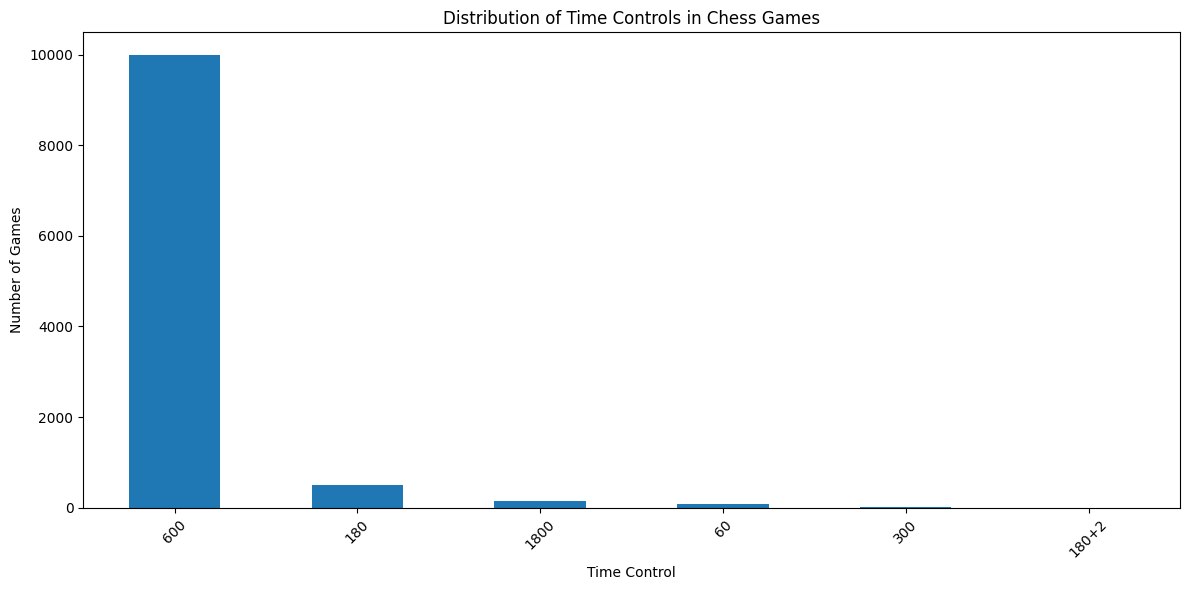

In [5]:
# Create a bar plot for unique time controls
plt.figure(figsize=(12, 6))
time_control_counts = raw_chess_nov2['time_control'].value_counts()
time_control_counts.plot(kind='bar')
plt.title('Distribution of Time Controls in Chess Games')
plt.xlabel('Time Control')
plt.ylabel('Number of Games')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Looks like I mostly play blitz and bullet games, so I want to focus on those.

In [6]:
# Extract 10-minute and 3-minute game datasets (using string comparison)
print("🕘 Creating 10-minute games dataset...")
games_10min = raw_chess_nov2[raw_chess_nov2['time_control'] == '600'].copy()

print("🕒 Creating 3-minute games dataset...")
games_3min = raw_chess_nov2[raw_chess_nov2['time_control'] == '180'].copy()

print("📈 Dataset Summary:")
print(f"Original dataset: {raw_chess_nov2.shape[0]:,} games")
print(f"10-minute games: {games_10min.shape[0]:,} games ({games_10min.shape[0]/raw_chess_nov2.shape[0]*100:.1f}%)")
print(f"3-minute games: {games_3min.shape[0]:,} games ({games_3min.shape[0]/raw_chess_nov2.shape[0]*100:.1f}%)")

# Verify the filtering worked correctly
print("\n✅ Verification:")
print(f"10-min dataset time controls: {games_10min['time_control'].unique()}")
print(f"3-min dataset time controls: {games_3min['time_control'].unique()}")

# Show basic info about each dataset
print(f"\n📊 10-minute games info:")
print(f"  - Total games: {len(games_10min):,}")
print(f"  - Columns: {games_10min.shape[1]}")
print(f"  - Memory usage: {games_10min.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

print(f"\n📊 3-minute games info:")
print(f"  - Total games: {len(games_3min):,}")
print(f"  - Columns: {games_3min.shape[1]}")
print(f"  - Memory usage: {games_3min.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

print("\n🎯 Both datasets are ready for analysis!")
print("📌 Variables created: 'games_10min' and 'games_3min'")

🕘 Creating 10-minute games dataset...
🕒 Creating 3-minute games dataset...
📈 Dataset Summary:
Original dataset: 10,736 games
10-minute games: 9,993 games (93.1%)
3-minute games: 491 games (4.6%)

✅ Verification:
10-min dataset time controls: ['600']
3-min dataset time controls: ['180']

📊 10-minute games info:
  - Total games: 9,993
  - Columns: 24
  - Memory usage: 37.2 MB

📊 3-minute games info:
  - Total games: 491
  - Columns: 24
  - Memory usage: 1.9 MB

🎯 Both datasets are ready for analysis!
📌 Variables created: 'games_10min' and 'games_3min'


In [7]:
# Time Series Preparation: Convert timestamps to datetime
print("=" * 60)
print("TIME SERIES ANALYSIS: 10-Minute Games")
print("=" * 60)

# Convert end_time to datetime
games_10min['datetime'] = pd.to_datetime(games_10min['end_time'], unit='s')

# Create time period columns
games_10min['year'] = games_10min['datetime'].dt.year
games_10min['year_month'] = games_10min['datetime'].dt.to_period('M')
games_10min['year_week'] = games_10min['datetime'].dt.to_period('W')
games_10min['date'] = games_10min['datetime'].dt.date

print("\nDate range:")
print(f"First game: {games_10min['datetime'].min()}")
print(f"Last game: {games_10min['datetime'].max()}")
print(f"Total span: {(games_10min['datetime'].max() - games_10min['datetime'].min()).days} days")
print("\nTime series columns created successfully!")

TIME SERIES ANALYSIS: 10-Minute Games

Date range:
First game: 2019-11-10 18:52:00
Last game: 2025-10-30 01:54:16
Total span: 2180 days

Time series columns created successfully!


In [ ]:
# Bar plot: Hours spent on Chess.com each year
import plotly.express as px

# Calculate hours per year for 10-minute games
yearly_hours = games_10min.groupby('year')['game_duration_minutes'].sum() / 60
yearly_hours_df = yearly_hours.reset_index()
yearly_hours_df.columns = ['Year', 'Hours']

# Create bar plot
fig = px.bar(yearly_hours_df, 
             x='Year', 
             y='Hours',
             title='⏰ Hours Spent Playing 10-Minute Chess Games by Year',
             labels={'Hours': 'Total Hours', 'Year': 'Year'},
             text='Hours')

# Format the bars
fig.update_traces(texttemplate='%{text:.1f}h', textposition='outside')
fig.update_layout(
    xaxis=dict(tickmode='linear', dtick=1),
    yaxis_title='Hours Played',
    showlegend=False,
    height=500
)

fig.show()

print("\n📊 Yearly Hours Summary:")
for year, hours in yearly_hours_df.itertuples(index=False):
    print(f"  {year}: {hours:.1f} hours ({hours/12:.1f} hours/month average)")
